# 📈 Sales & Demand Forecasting for Businesses

## Future Interns – Machine Learning Task 1

### Submitted by
**Pallavi B**

---

## Project Objective

The objective of this project is to build a machine learning model that forecasts future weekly sales using historical Walmart sales data. Accurate sales forecasting helps businesses improve inventory management, demand planning, resource allocation, and overall decision-making.

# 1. Dataset Upload

The Walmart Sales Forecast dataset is uploaded into Google Colab. The dataset contains historical sales information that will be used to train and evaluate a forecasting model.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


# 2. Dataset Extraction

The compressed dataset is extracted to access the CSV files required for analysis. These files include training data, testing data, store information, and additional business features.

In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("walmart_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# 3. Verify Dataset Files

This step verifies that all required dataset files have been extracted successfully and are available for further processing.

In [ ]:
import os

os.listdir("walmart_dataset")

['features.csv', 'test.csv', 'train.csv', 'stores.csv']

# 4. Import Required Libraries

Python libraries such as Pandas, NumPy, Matplotlib, and Scikit-learn are imported for data manipulation, visualization, machine learning model development, and evaluation.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 5. Load the Dataset

The four CSV files are loaded into Pandas DataFrames. These datasets contain sales records, store details, and additional features required for forecasting.

In [ ]:
# Load all CSV files

train = pd.read_csv("walmart_dataset/train.csv")
test = pd.read_csv("walmart_dataset/test.csv")
features = pd.read_csv("walmart_dataset/features.csv")
stores = pd.read_csv("walmart_dataset/stores.csv")

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Features Shape :", features.shape)
print("Stores Shape :", stores.shape)

Train Shape : (421570, 5)
Test Shape : (115064, 4)
Features Shape : (8190, 12)
Stores Shape : (45, 3)


# 6. Explore the Dataset

The first few rows of each dataset are displayed to understand the available features, data types, and overall structure before preprocessing.

In [ ]:
# Display first 5 rows
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


# 7. Merge the Datasets

The training dataset is merged with the Features and Stores datasets to create one comprehensive dataset for machine learning analysis.

In [ ]:
# Merge train with features
data = pd.merge(train, features, on=["Store", "Date", "IsHoliday"], how="left")

# Merge with stores
data = pd.merge(data, stores, on="Store", how="left")

print("Merged Dataset Shape:", data.shape)

data.head()

Merged Dataset Shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# 8. Data Cleaning

Missing values are identified and handled appropriately. The MarkDown columns are filled with zero because missing values indicate that no promotional markdown was applied during those weeks.

In [ ]:
# Check missing values
data.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [ ]:
# Fill missing values in MarkDown columns with 0
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    data[col] = data[col].fillna(0)

# Check again
data.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


# 9. Feature Engineering

The Date column is converted into Year, Month, Week, and Day features. These time-based features help the model identify seasonal sales trends.

In [ ]:
# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Create time-based features
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)
data["Day"] = data["Date"].dt.day

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,5


# 10. Exploratory Data Analysis (EDA)

EDA is performed to understand sales patterns, seasonal trends, store performance, and relationships between business variables before model development.

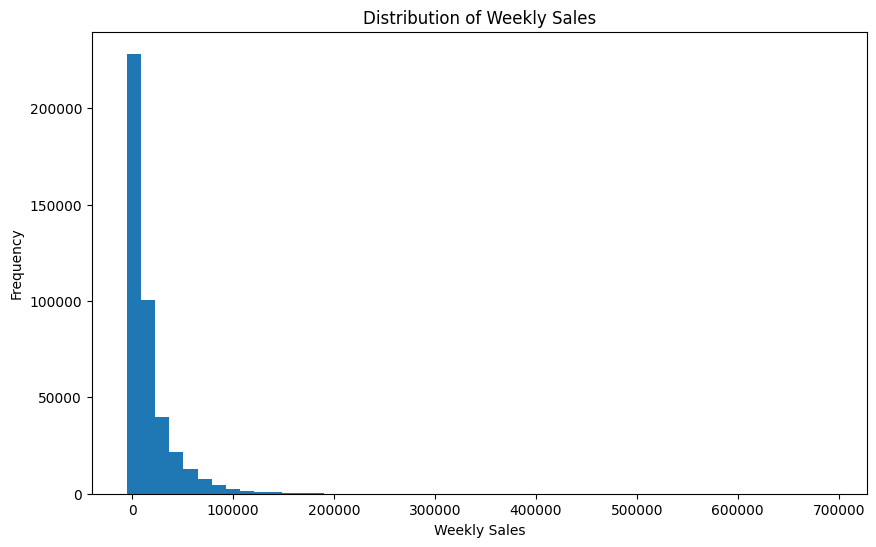

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(data["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

Business Insight

The sales distribution is right-skewed, indicating that most stores generate moderate weekly sales, while a few stores achieve exceptionally high sales. This suggests that businesses should investigate the factors contributing to the performance of high-selling stores and apply similar strategies where appropriate.

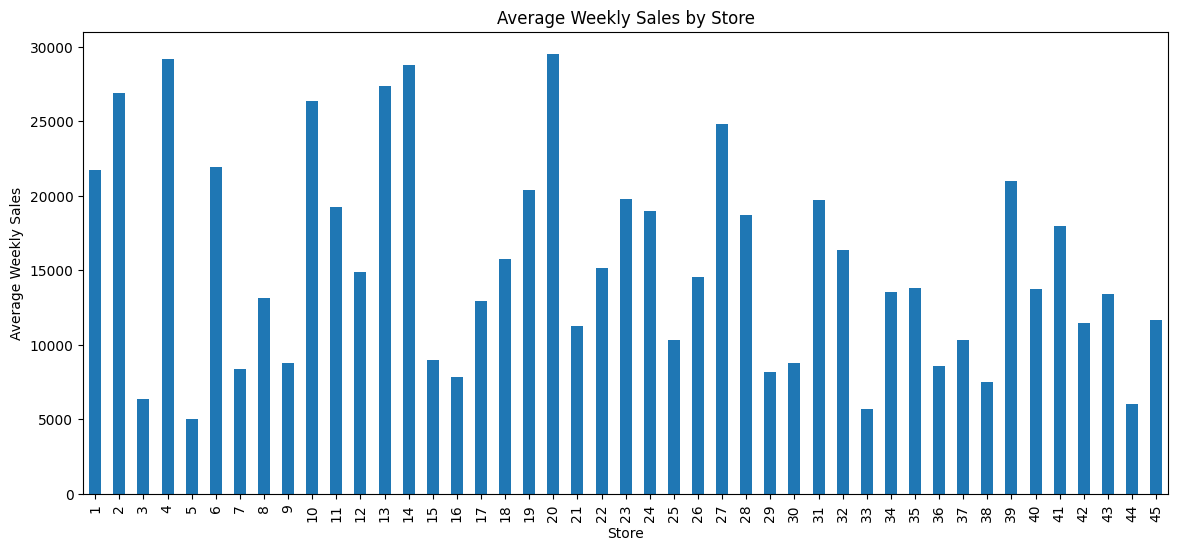

In [ ]:
store_sales = data.groupby("Store")["Weekly_Sales"].mean()

plt.figure(figsize=(14,6))
store_sales.plot(kind="bar")
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

Business Insight

Sales performance varies significantly across stores. High-performing stores may benefit from better customer demand, location, or operational practices. Studying these stores can help improve the performance of lower-selling locations.

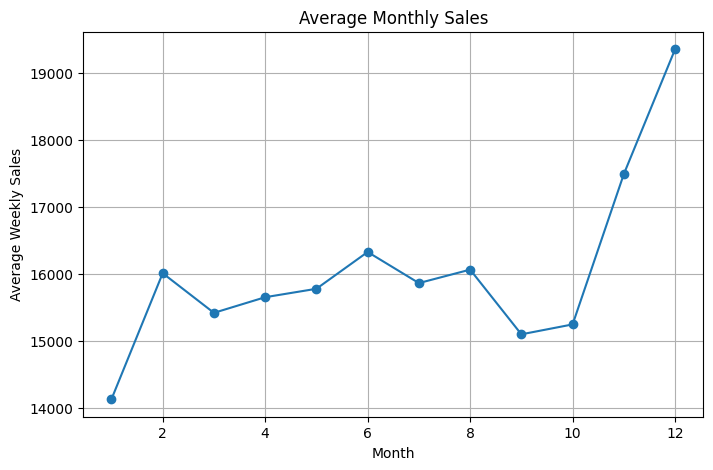

In [ ]:
monthly_sales = data.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.grid(True)
plt.show()

Business Insight

Monthly sales fluctuate throughout the year, with higher sales observed toward the end of the year. This indicates seasonal demand, emphasizing the importance of inventory planning, staffing, and marketing campaigns during peak sales months.

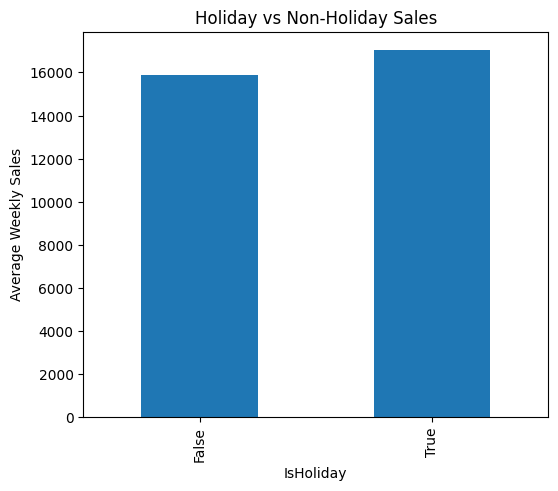

In [ ]:
holiday_sales = data.groupby("IsHoliday")["Weekly_Sales"].mean()

plt.figure(figsize=(6,5))
holiday_sales.plot(kind="bar")
plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("Average Weekly Sales")
plt.show()

Business Insight

Average sales during holiday periods are slightly higher than during non-holiday periods. Businesses can leverage this trend by introducing special promotions, discounts, and ensuring adequate stock availability during holidays.

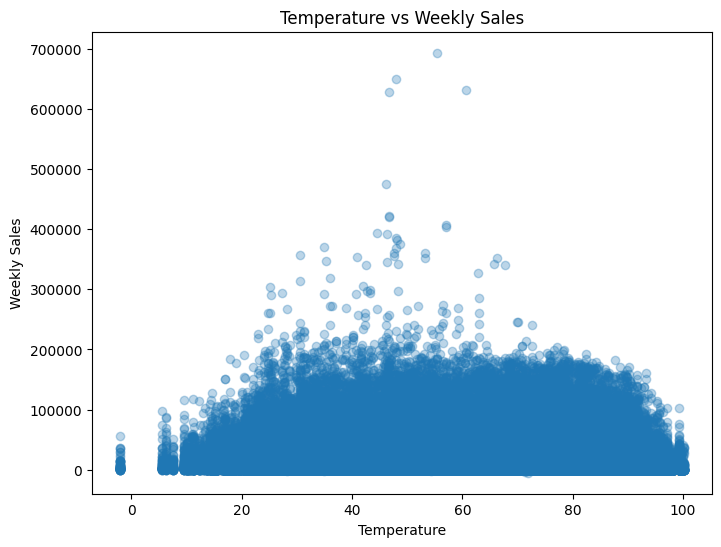

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data["Temperature"], data["Weekly_Sales"], alpha=0.3)
plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

Business Insight

The scatter plot does not show a strong relationship between temperature and weekly sales. This suggests that customer demand is influenced more by factors such as promotions, holidays, and store characteristics than by weather alone.

In [ ]:
# Convert categorical columns into numeric values
data["Type"] = data["Type"].map({"A": 0, "B": 1, "C": 2})

data["IsHoliday"] = data["IsHoliday"].astype(int)

# Drop Date column (already extracted into Year, Month, Week, Day)
data = data.drop("Date", axis=1)

data.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,151315,2010,2,5,5
1,1,1,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,151315,2010,2,6,12
2,1,1,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,151315,2010,2,7,19
3,1,1,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,151315,2010,2,8,26
4,1,1,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,151315,2010,3,9,5


In [ ]:
# Input features
X = data.drop("Weekly_Sales", axis=1)

# Target variable
y = data["Weekly_Sales"]

print(X.shape)
print(y.shape)

(421570, 18)
(421570,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (337256, 18)
Testing Data: (84314, 18)


# 11. Machine Learning Model

A Random Forest Regressor is selected to forecast weekly sales. This ensemble learning algorithm provides high accuracy by combining multiple decision trees.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [23]:
predictions = model.predict(X_test)

predictions[:10]

array([50444.3686,  3458.2608, 10369.8038,  3733.401 ,  5283.2839,
        8823.6518,  1546.9018, 19690.044 ,  7213.3932, 16310.6737])

# 12. Model Evaluation

The trained model is evaluated using MAE, MSE, RMSE, and R² Score to measure prediction accuracy and overall performance.

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 1330.7661331985198
Mean Squared Error : 11573561.093348674
Root Mean Squared Error : 3401.993693901956
R² Score : 0.9778059350348914


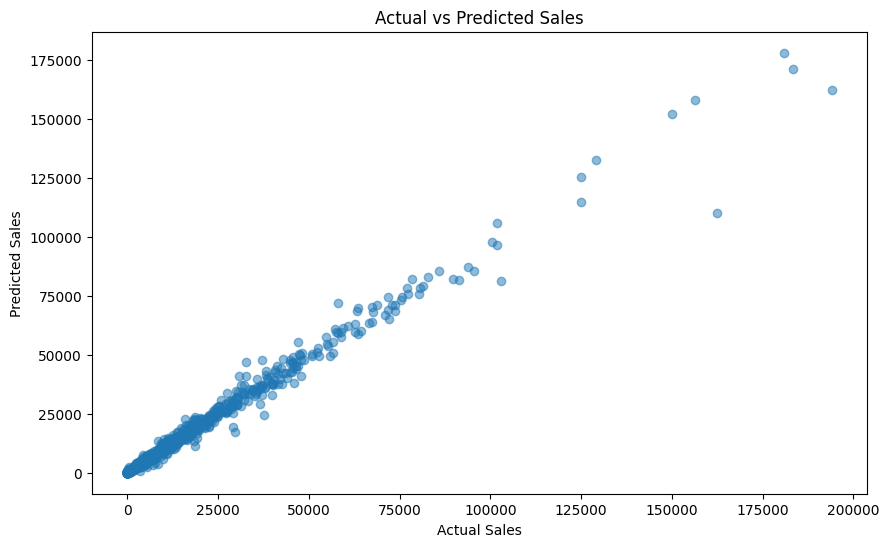

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test[:1000],
    predictions[:1000],
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

Business Insight

The predicted sales closely match the actual sales, demonstrating that the Random Forest model effectively captures historical sales patterns. This makes the model suitable for forecasting future sales and supporting inventory and business planning.

# 13. Feature Importance

Feature importance analysis identifies the variables that contribute the most to predicting weekly sales.

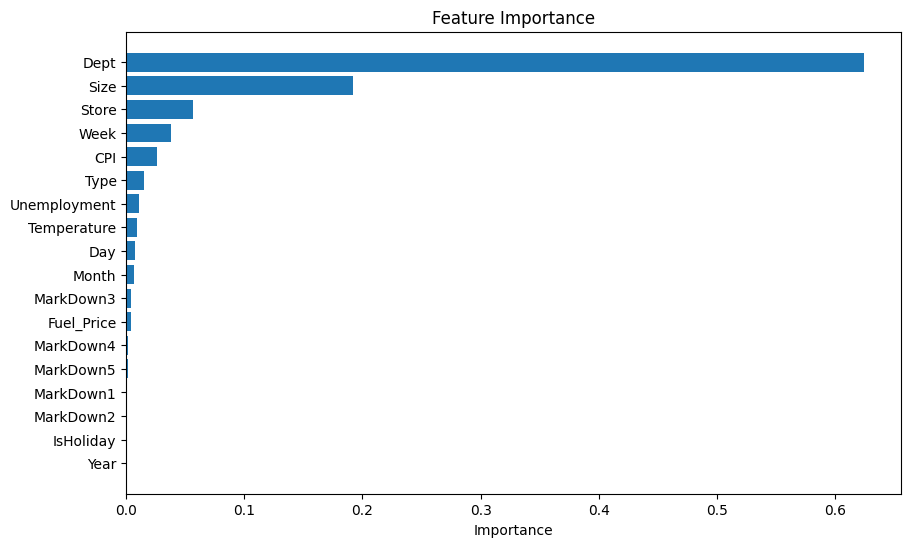

,Feature,Importance
1,Dept,0.625100
13,Size,0.192029
0,Store,0.056845
16,Week,0.037822
10,CPI,0.025656
12,Type,0.014659
11,Unemployment,0.010898
3,Temperature,0.009365
17,Day,0.007700
15,Month,0.006424


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

importance.head(10)

Business Insight

The feature importance analysis identifies the variables that have the greatest influence on sales predictions. Businesses can focus on these key drivers when making strategic decisions related to pricing, promotions, inventory management, and seasonal planning.

Model Performance

The Random Forest Regressor achieved excellent predictive performance.

MAE: 1330.77
RMSE: 3401.99
R² Score: 0.978

These metrics indicate that the model can accurately forecast weekly sales and can support inventory planning and business decision-making.

Business Recommendations
Increase inventory before high-demand periods such as holidays.
Analyze the strategies of high-performing stores and replicate successful practices.
Use demand forecasts to optimize staffing and logistics.
Monitor external factors like fuel prices and seasonal trends when planning promotions.

# 14. Conclusion

This project successfully developed a machine learning model to forecast weekly sales using historical Walmart sales data.

The project included:
- Data preprocessing
- Data cleaning
- Feature engineering
- Exploratory Data Analysis
- Machine Learning model development
- Model evaluation
- Business insights

The Random Forest model achieved excellent performance with an R² score of approximately **0.978**, indicating strong predictive capability. This forecasting model can support inventory management, demand planning, and strategic business decision-making.

